# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the master dataset and generate business insights.

The analysis focuses on:

- Order trends
- Product performance
- Customer performance
- City-wise demand
- Currency comparison
- Revenue analysis
- Delivery performance

These insights will support KPI calculation and dashboard development.


In [1]:
import pandas as pd

In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
orders = pd.read_csv("master_dataset.csv")

In [4]:
orders["order_placement_date"] = pd.to_datetime(
    orders["order_placement_date"]
)

orders["agreed_delivery_date"] = pd.to_datetime(
    orders["agreed_delivery_date"]
)

orders["actual_delivery_date"] = pd.to_datetime(
    orders["actual_delivery_date"]
)

print("Date columns converted successfully.")

Date columns converted successfully.


# Dataset Overview

Before performing any analysis, let's understand the structure of the master dataset.

In [5]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(orders.shape)

Dataset Shape
(24195, 24)


In [6]:
print("="*60)
print("Dataset Information")
print("="*60)

orders.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 24195 entries, 0 to 24194
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              24195 non-null  str           
 1   order_placement_date  24195 non-null  datetime64[us]
 2   customer_id           24195 non-null  int64         
 3   product_id            24195 non-null  int64         
 4   order_qty             24195 non-null  int64         
 5   agreed_delivery_date  24195 non-null  datetime64[us]
 6   actual_delivery_date  24195 non-null  datetime64[us]
 7   delivery_qty          24195 non-null  int64         
 8   In Full               24195 non-null  int64         
 9   On Time               24195 non-null  int64         
 10  On Time In Full       24195 non-null  int64         
 11  customer_name         24195 non-null  str           
 12  city                  24195 non-null  str           
 13  currenc

In [7]:
print("="*60)
print("First Five Rows")
print("="*60)

orders.head()

First Five Rows


,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty,In Full,On Time,...,product_name,category,price_INR,price_USD,on_time,in_full,otif,ontime_target%,infull_target%,otif_target%
0,FMR34203601,2025-03-01,789203,25891601,110,2025-03-04,2025-03-04,110,1,1,...,AM Tea 500,beverages,225,6.0,1,1,1,92,76,70
1,FMR32320302,2025-03-01,789320,25891203,347,2025-03-02,2025-03-02,347,1,1,...,AM Butter 500,Dairy,300,9.0,1,1,1,91,81,74
2,FMR33320501,2025-03-01,789320,25891203,187,2025-03-03,2025-03-03,150,0,1,...,AM Butter 500,Dairy,300,9.0,1,0,0,91,81,74
3,FMR34220601,2025-03-01,789220,25891203,235,2025-03-04,2025-03-04,235,1,1,...,AM Butter 500,Dairy,300,9.0,1,1,1,91,76,69
4,FMR33703603,2025-03-01,789703,25891203,176,2025-03-03,2025-03-03,176,1,1,...,AM Butter 500,Dairy,300,9.0,1,1,1,85,78,66


In [8]:
print("="*60)
print("Missing Values")
print("="*60)

print(orders.isnull().sum())

Missing Values
order_id                0
order_placement_date    0
customer_id             0
product_id              0
order_qty               0
agreed_delivery_date    0
actual_delivery_date    0
delivery_qty            0
In Full                 0
On Time                 0
On Time In Full         0
customer_name           0
city                    0
currency                0
product_name            0
category                0
price_INR               0
price_USD               0
on_time                 0
in_full                 0
otif                    0
ontime_target%          0
infull_target%          0
otif_target%            0
dtype: int64


# Feature Engineering

To perform time-based analysis, additional date-related features are created from the order placement date.

In [9]:
orders["Month"] = orders["order_placement_date"].dt.month_name()

orders["Month_Number"] = orders["order_placement_date"].dt.month

orders["Year"] = orders["order_placement_date"].dt.year

orders["Quarter"] = orders["order_placement_date"].dt.quarter

orders["Weekday"] = orders["order_placement_date"].dt.day_name()

print("Date features created successfully.")

Date features created successfully.


In [10]:
print("="*60)
print("New Columns")
print("="*60)

print(
    orders[
        [
            "order_placement_date",
            "Month",
            "Month_Number",
            "Year",
            "Quarter",
            "Weekday"
        ]
    ].head()
)

New Columns
  order_placement_date  Month  Month_Number  Year  Quarter   Weekday
0           2025-03-01  March             3  2025        1  Saturday
1           2025-03-01  March             3  2025        1  Saturday
2           2025-03-01  March             3  2025        1  Saturday
3           2025-03-01  March             3  2025        1  Saturday
4           2025-03-01  March             3  2025        1  Saturday


# Revenue Calculation

The dataset contains customers from both India (INR) and the United States (USD).

Revenue is calculated using the appropriate price based on the customer's currency.

In [37]:
orders["Revenue"] = orders.apply(
    lambda row: row["order_qty"] * row["price_INR"]
    if row["currency"] == "INR"
    else row["order_qty"] * row["price_USD"],
    axis=1
)

print("Revenue calculated successfully.")

Revenue calculated successfully.


In [12]:
print("="*60)
print("Revenue Sample")
print("="*60)

print(
    orders[
        [
            "currency",
            "order_qty",
            "price_INR",
            "price_USD",
            "Revenue"
        ]
    ].head()
)

Revenue Sample
  currency  order_qty  price_INR  price_USD  Revenue
0      INR        110        225        6.0  24750.0
1      USD        347        300        9.0   3123.0
2      USD        187        300        9.0   1683.0
3      USD        235        300        9.0   2115.0
4      INR        176        300        9.0  52800.0


# Business Question 1: How many orders are placed each month?

Understanding monthly order volume helps identify demand patterns and seasonal trends.

In [13]:
## Since each order_id can have multiple product lines, count unique orders, not rows.
monthly_orders = (
    orders.groupby("Month")["order_id"]
          .nunique()
          .reset_index(name="Total Orders")
)

print(monthly_orders)

   Month  Total Orders
0  April          5253
1  March          5407
2    May          2807


In [14]:
## To display months in calendar order instead of alphabetical order:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_orders["Month"] = pd.Categorical(
    monthly_orders["Month"],
    categories=month_order,
    ordered=True
)

monthly_orders = monthly_orders.sort_values("Month")

print(monthly_orders)

   Month  Total Orders
1  March          5407
0  April          5253
2    May          2807


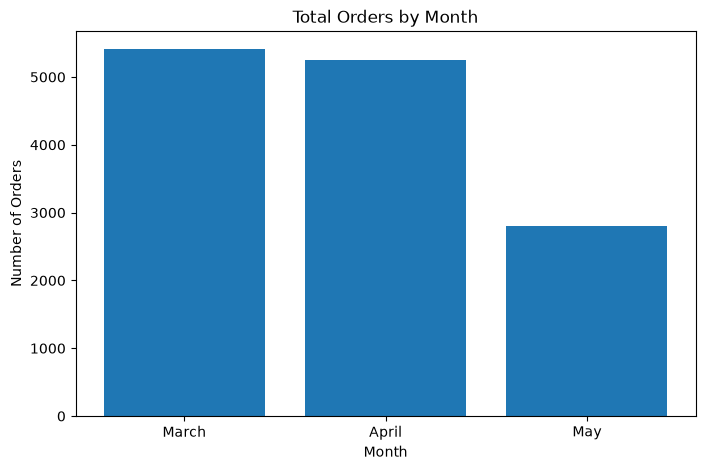

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(
    monthly_orders["Month"],
    monthly_orders["Total Orders"]
)

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

In [16]:
print("Minimum Date :", orders["order_placement_date"].min())
print("Maximum Date :", orders["order_placement_date"].max())

Minimum Date : 2025-03-01 00:00:00
Maximum Date : 2025-05-16 00:00:00


### Business Insight

- March recorded the highest number of unique orders (5,407).
- April had a slightly lower order volume (5,253), indicating relatively stable demand.
- May recorded only 2,807 orders; however, this should not be interpreted as lower demand because the dataset includes data only up to **16 May 2025**, making it a partial month.

# Business Question 2: Which Products Are Ordered the Most?

This analysis identifies the products with the highest total ordered quantity.

Understanding product demand helps improve:

- Inventory planning
- Production scheduling
- Procurement decisions
- Warehouse stocking

In [17]:
product_orders = (
    orders.groupby("product_name")["order_qty"]
          .sum()
          .reset_index(name="Total Order Quantity")
)

product_orders = product_orders.sort_values(
    by="Total Order Quantity",
    ascending=False
)

print(product_orders.head(10))

       product_name  Total Order Quantity
13      AM Milk 250                550398
14      AM Milk 500                533011
12      AM Milk 100                519660
8        AM Curd 50                473736
6       AM Curd 100                464765
7       AM Curd 250                459198
5     AM Butter 500                421543
4     AM Butter 250                398292
3     AM Butter 100                393492
0   AM Biscuits 250                244441


In [18]:
top_products = product_orders.head(10)

top_products

,product_name,Total Order Quantity
13,AM Milk 250,550398
14,AM Milk 500,533011
12,AM Milk 100,519660
8,AM Curd 50,473736
6,AM Curd 100,464765
7,AM Curd 250,459198
5,AM Butter 500,421543
4,AM Butter 250,398292
3,AM Butter 100,393492
0,AM Biscuits 250,244441


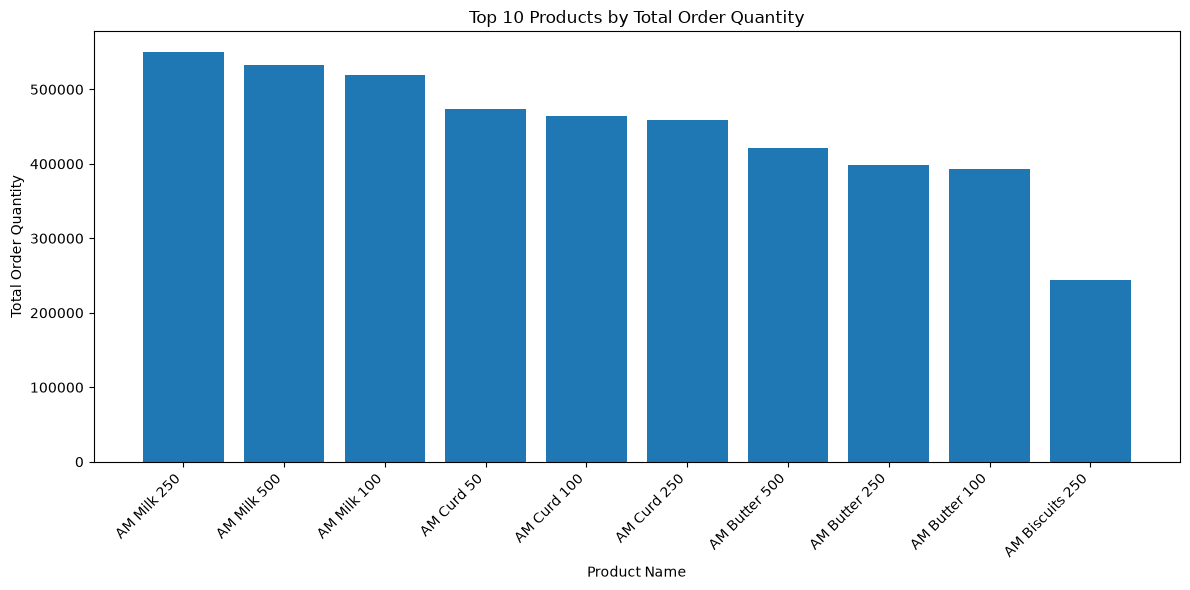

In [19]:
plt.figure(figsize=(12,6))

plt.bar(
    top_products["product_name"],
    top_products["Total Order Quantity"]
)

plt.title("Top 10 Products by Total Order Quantity")

plt.xlabel("Product Name")
plt.ylabel("Total Order Quantity")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Business Insight

- **AM Milk 250** is the highest-demand product with a total order quantity of **550,398**, followed closely by **AM Milk 500** and **AM Milk 100**.
- Milk products occupy the top three positions, indicating consistently high customer demand across different package sizes.
- Curd products also show strong demand, with all three variants ranking in the top six.
- Dairy products (Milk, Curd, and Butter) dominate the top-selling products, suggesting that inventory, production, and procurement efforts should prioritize these items.
- **AM Biscuits 250** has the lowest demand among the top 10 products, indicating comparatively lower customer preference than dairy products.

# Business Question 3: Which Product Categories Generate the Highest Demand?

This analysis evaluates customer demand across different product categories.

The insights help the business:

- Allocate inventory efficiently
- Plan production capacity
- Prioritize procurement
- Understand customer purchasing behavior

In [20]:
category_orders = (
    orders.groupby("category")["order_qty"]
          .sum()
          .reset_index(name="Total Order Quantity")
)

category_orders = category_orders.sort_values(
    by="Total Order Quantity",
    ascending=False
)

category_orders

,category,Total Order Quantity
0,Dairy,4453599
1,Food,720325
2,beverages,502524


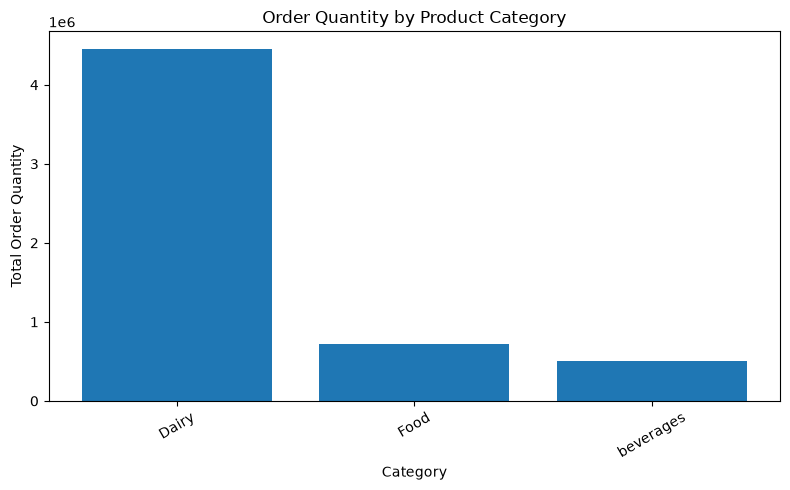

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    category_orders["category"],
    category_orders["Total Order Quantity"]
)

plt.title("Order Quantity by Product Category")

plt.xlabel("Category")

plt.ylabel("Total Order Quantity")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

### Business Insight

- **Dairy** is the highest-demand product category with a total order quantity of **4,453,599**, contributing significantly more than the other categories.
- **Food** ranks second with **720,325** units ordered, while **Beverages** has the lowest demand at **502,524** units.
- The strong demand for Dairy products indicates that inventory planning, procurement, and production resources should be primarily focused on this category.
- Since Food and Beverages contribute a much smaller share of total demand, businesses can optimize stock levels for these categories while maintaining high product availability for Dairy items.

# Business Question 4: Which Customers Place the Most Orders?

This analysis identifies the customers placing the highest number of unique orders.

The insights help the business:

- Identify key customers
- Improve customer relationship management
- Prioritize service levels
- Support customer retention strategies

In [22]:
## count unique order for each customer 
customer_orders = (
    orders.groupby("customer_name")["order_id"]
          .nunique()
          .reset_index(name="Total Orders")
)

customer_orders = customer_orders.sort_values(
    by="Total Orders",
    ascending=False
)

top_customers = customer_orders.head(10)

top_customers

,customer_name,Total Orders
5,Coolblue,1029
0,Acclaimed Stores,1018
18,Rel Fresh,1005
15,Lotus Mart,983
21,Vijay Stores,713
8,Expert Mart,711
7,Elite Mart,698
20,Sorefoz Mart,695
17,Propel Mart,677
13,Lidl,507


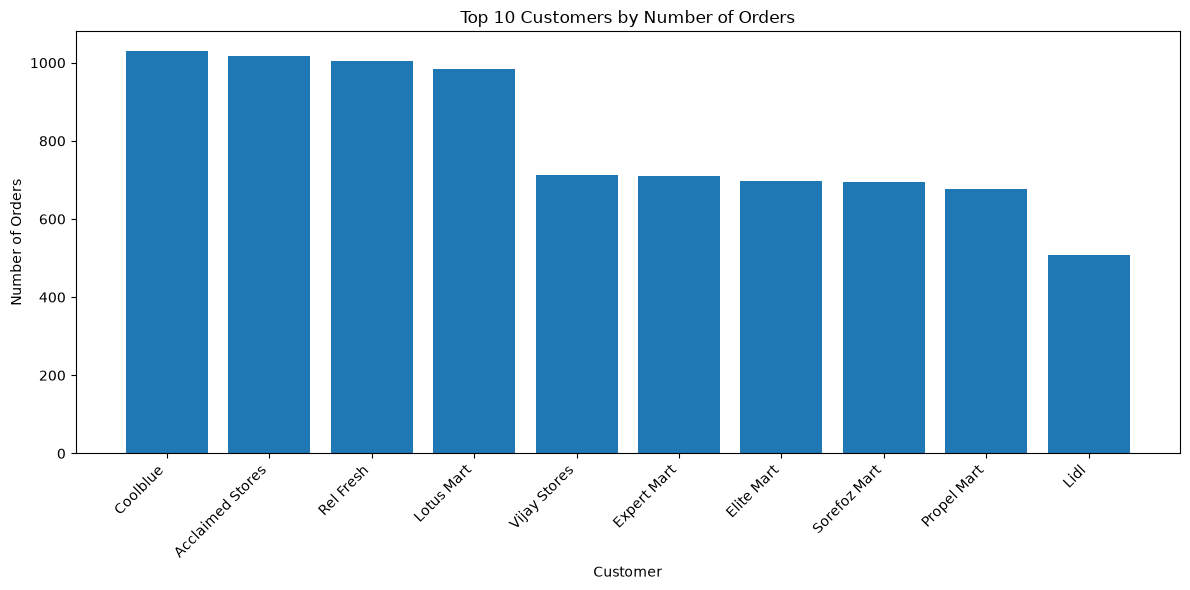

In [23]:
plt.figure(figsize=(12,6))

plt.bar(
    top_customers["customer_name"],
    top_customers["Total Orders"]
)

plt.title("Top 10 Customers by Number of Orders")

plt.xlabel("Customer")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

### Business Insight

- **Coolblue** is the company's largest customer, placing **1,029 unique orders**, closely followed by **Acclaimed Stores (1,018)** and **Rel Fresh (1,005)**.
- The top four customers each placed nearly **1,000 orders**, highlighting their importance to the business.
- These high-value customers should receive priority in inventory allocation, delivery scheduling, and customer relationship management to maintain service quality.
- Customers with lower order volumes may represent opportunities for targeted marketing and business growth initiatives.

# Business Question 5: Which Cities Generate the Highest Revenue?

This analysis evaluates revenue generated by customers across different cities.

The insights help the business:

- Identify high-value markets
- Support regional sales strategies
- Improve inventory allocation
- Guide future expansion decisions

# Business Question 5: Which Cities Generate the Highest Revenue?

This analysis evaluates revenue generated by customers across different cities.

The insights help the business:

- Identify high-value markets
- Support regional sales strategies
- Improve inventory allocation
- Guide future expansion decisions

In [24]:
city_revenue = (
    orders.groupby("city")["Revenue"]
          .sum()
          .reset_index(name="Total Revenue")
)

city_revenue = city_revenue.sort_values(
    by="Total Revenue",
    ascending=False
)

city_revenue

,city,Total Revenue
0,Ahmedabad,207955477.0
2,Vadodara,205007401.0
1,"New Jersey, US",6200471.0


In [25]:
city_revenue["Currency"] = city_revenue["city"].apply(
    lambda x: "₹ INR" if x in ["Ahmedabad", "Vadodara"] else "$ USD"
)

city_revenue

,city,Total Revenue,Currency
0,Ahmedabad,207955477.0,₹ INR
2,Vadodara,205007401.0,₹ INR
1,"New Jersey, US",6200471.0,$ USD


In [26]:
city_revenue["Total Revenue"] = city_revenue["Total Revenue"].map("{:,.0f}".format)

city_revenue

,city,Total Revenue,Currency
0,Ahmedabad,"207,955,477",₹ INR
2,Vadodara,"205,007,401",₹ INR
1,"New Jersey, US","6,200,471",$ USD


## Business Insights

- The company operates in both **domestic (India)** and **international (United States)** markets, indicating a geographically diversified customer base.

- **Ahmedabad (₹207.96 million)** and **Vadodara (₹205.01 million)** are the company's highest revenue-generating cities, making them the primary domestic markets.

- **New Jersey, US ($6.20 million)** represents the company's international operations, demonstrating that the business has expanded beyond India.

- Revenue is recorded in **different currencies** (INR for India and USD for the United States). Therefore, the reported values should **not be directly compared** without converting them into a common currency.

- The strong revenue contribution from Ahmedabad and Vadodara suggests that inventory planning, warehouse operations, transportation, and customer service should be prioritized in these regions to maintain high service levels.

- The international market provides an opportunity for future business expansion. Management can evaluate customer demand, logistics costs, and delivery performance in the US before increasing investments.

- For executive reporting, revenue should be standardized into a single currency (e.g., INR or USD) to enable accurate comparison of regional performance and support strategic decision-making.

**Note:** Revenue is reported in the original transaction currency (INR for India and USD for the United States). Since exchange-rate information is not available in the dataset, revenue values are presented separately and are not directly compared.

# Business Question 6: Delivery Performance Analysis

Delivery performance is a key indicator of supply chain efficiency.

This analysis measures three important KPIs:

- On-Time Delivery (OT)
- In-Full Delivery (IF)
- On-Time In-Full (OTIF)

These KPIs help evaluate whether customer orders are delivered on time, in the requested quantity, and according to service level agreements.

In [27]:
delivery_performance = (
    orders[
        ["order_id", "on_time", "in_full", "otif"]
    ]
    .drop_duplicates()
)

delivery_performance.head()

,order_id,on_time,in_full,otif
0,FMR34203601,1,1,1
1,FMR32320302,1,1,1
2,FMR33320501,1,0,0
3,FMR34220601,1,1,1
4,FMR33703603,1,1,1


In [28]:
on_time_rate = delivery_performance["on_time"].mean() * 100

in_full_rate = delivery_performance["in_full"].mean() * 100

otif_rate = delivery_performance["otif"].mean() * 100

print(f"On Time Rate : {on_time_rate:.2f}%")
print(f"In Full Rate : {in_full_rate:.2f}%")
print(f"OTIF Rate    : {otif_rate:.2f}%")

On Time Rate : 59.22%
In Full Rate : 52.56%
OTIF Rate    : 28.71%


In [29]:
kpi_summary = pd.DataFrame({
    "KPI": ["On Time", "In Full", "OTIF"],
    "Percentage": [
        round(on_time_rate, 2),
        round(in_full_rate, 2),
        round(otif_rate, 2)
    ]
})

kpi_summary

,KPI,Percentage
0,On Time,59.22
1,In Full,52.56
2,OTIF,28.71


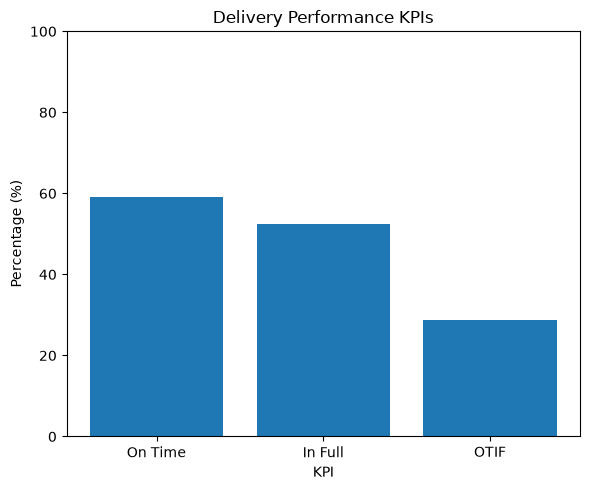

In [30]:
plt.figure(figsize=(6,5))

plt.bar(
    kpi_summary["KPI"],
    kpi_summary["Percentage"]
)

plt.title("Delivery Performance KPIs")

plt.xlabel("KPI")
plt.ylabel("Percentage (%)")

plt.ylim(0,100)

plt.tight_layout()

plt.show()

## Business Insights

- The company achieved an **On-Time Delivery (OT) rate of 59.22%**, meaning nearly **6 out of every 10 orders** were delivered on or before the promised delivery date.

- The **In-Full (IF) delivery rate is 52.56%**, indicating that only about **half of the customer orders** were delivered with the complete requested quantity.

- The **On-Time In-Full (OTIF) rate is 28.71%**, which means **less than one-third of all orders** met both customer expectations—being delivered on time and in full.

- The large gap between **On-Time (59.22%)** and **OTIF (28.71%)** suggests that many orders met only one service criterion. Some orders were delivered on time but not in full, while others were delivered in full but after the promised date.

- An **OTIF rate below 30%** highlights a significant opportunity to improve overall supply chain performance by strengthening inventory availability, warehouse operations, and transportation planning.

- Improving OTIF should be a strategic priority because it directly impacts **customer satisfaction, service reliability, repeat business, and operational efficiency**.

# Business Question 7: Target vs Actual Delivery Performance

This analysis compares the company's actual delivery performance against customer-defined service level targets.

The comparison helps identify:

- Customers with the largest performance gaps
- KPIs requiring operational improvement
- Opportunities to improve customer satisfaction

In [31]:
delivery_data = (
    orders[
        [
            "customer_name",
            "order_id",
            "on_time",
            "in_full",
            "otif",
            "ontime_target%",
            "infull_target%",
            "otif_target%"
        ]
    ]
    .drop_duplicates()
)

delivery_data.head()

,customer_name,order_id,on_time,in_full,otif,ontime_target%,infull_target%,otif_target%
0,Rel Fresh,FMR34203601,1,1,1,92,76,70
1,Whole Foods Market,FMR32320302,1,1,1,91,81,74
2,Whole Foods Market,FMR33320501,1,0,0,91,81,74
3,ShopRite,FMR34220601,1,1,1,91,76,69
4,Sorefoz Mart,FMR33703603,1,1,1,85,78,66


In [32]:
## calculate actual performance by customer 
actual_performance = (
    delivery_data
    .groupby("customer_name")[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

actual_performance["on_time"] *= 100
actual_performance["in_full"] *= 100
actual_performance["otif"] *= 100

actual_performance.head()

,customer_name,on_time,in_full,otif
0,Acclaimed Stores,29.273084,66.601179,19.056974
1,Atlas Stores,70.509383,59.249330,39.410188
2,Best Market,72.781065,57.988166,39.940828
3,Chiptec Stores,72.622478,62.247839,40.634006
4,Colonial Farms,69.125683,63.387978,40.983607


In [33]:
## calculate target performance by customer 
target_performance = (
    delivery_data
    .groupby("customer_name")[
        [
            "ontime_target%",
            "infull_target%",
            "otif_target%"
        ]
    ]
    .mean()
    .reset_index()
)

target_performance.head()

,customer_name,ontime_target%,infull_target%,otif_target%
0,Acclaimed Stores,77.017682,79.0,61.017682
1,Atlas Stores,85.000000,80.0,68.000000
2,Best Market,92.000000,80.0,74.000000
3,Chiptec Stores,87.000000,81.0,70.000000
4,Colonial Farms,86.000000,77.0,66.000000


In [34]:
# Merge actual and Target 
customer_kpi = actual_performance.merge(
    target_performance,
    on="customer_name",
    how="inner"
)

customer_kpi.head()

,customer_name,on_time,in_full,otif,ontime_target%,infull_target%,otif_target%
0,Acclaimed Stores,29.273084,66.601179,19.056974,77.017682,79.0,61.017682
1,Atlas Stores,70.509383,59.249330,39.410188,85.000000,80.0,68.000000
2,Best Market,72.781065,57.988166,39.940828,92.000000,80.0,74.000000
3,Chiptec Stores,72.622478,62.247839,40.634006,87.000000,81.0,70.000000
4,Colonial Farms,69.125683,63.387978,40.983607,86.000000,77.0,66.000000


In [35]:
## Calculate the gap between actual and target performance for each KPI
## Calculate Performance Gap for each KPI
customer_kpi["OT Gap"] = (
    customer_kpi["on_time"]
    - customer_kpi["ontime_target%"]
)

customer_kpi["IF Gap"] = (
    customer_kpi["in_full"]
    - customer_kpi["infull_target%"]
)

customer_kpi["OTIF Gap"] = (
    customer_kpi["otif"]
    - customer_kpi["otif_target%"]
)

customer_kpi.head()                                             

,customer_name,on_time,in_full,otif,ontime_target%,infull_target%,otif_target%,OT Gap,IF Gap,OTIF Gap
0,Acclaimed Stores,29.273084,66.601179,19.056974,77.017682,79.0,61.017682,-47.744597,-12.398821,-41.960707
1,Atlas Stores,70.509383,59.249330,39.410188,85.000000,80.0,68.000000,-14.490617,-20.750670,-28.589812
2,Best Market,72.781065,57.988166,39.940828,92.000000,80.0,74.000000,-19.218935,-22.011834,-34.059172
3,Chiptec Stores,72.622478,62.247839,40.634006,87.000000,81.0,70.000000,-14.377522,-18.752161,-29.365994
4,Colonial Farms,69.125683,63.387978,40.983607,86.000000,77.0,66.000000,-16.874317,-13.612022,-25.016393


In [36]:
## Round the values to 2 decimal places for better readability
customer_kpi = customer_kpi.round(2)

customer_kpi

,customer_name,on_time,in_full,otif,ontime_target%,infull_target%,otif_target%,OT Gap,IF Gap,OTIF Gap
0,Acclaimed Stores,29.27,66.60,19.06,77.02,79.00,61.02,-47.74,-12.40,-41.96
1,Atlas Stores,70.51,59.25,39.41,85.00,80.00,68.00,-14.49,-20.75,-28.59
2,Best Market,72.78,57.99,39.94,92.00,80.00,74.00,-19.22,-22.01,-34.06
3,Chiptec Stores,72.62,62.25,40.63,87.00,81.00,70.00,-14.38,-18.75,-29.37
4,Colonial Farms,69.13,63.39,40.98,86.00,77.00,66.00,-16.87,-13.61,-25.02
5,Coolblue,30.03,43.63,14.09,76.99,70.96,54.46,-46.96,-27.32,-40.37
6,Costco Wholesale,71.47,56.23,35.73,86.00,80.00,69.00,-14.53,-23.77,-33.27
7,Elite Mart,74.07,37.54,25.07,91.00,73.00,66.50,-16.93,-35.46,-41.43
8,Expert Mart,71.03,59.35,37.55,91.00,80.00,73.01,-19.98,-20.65,-35.46
9,Expression Stores,71.81,65.88,43.92,88.00,78.00,69.00,-16.19,-12.12,-25.08


## Business Insights

- The analysis shows that **none of the customers achieved their agreed service-level targets** for On-Time Delivery (OT), In-Full Delivery (IF), or OTIF, highlighting a company-wide gap in delivery performance.

- **Acclaimed Stores** has the largest OTIF performance gap (**-41.96 percentage points**), indicating the biggest difference between expected and actual delivery performance. This customer should be treated as the highest priority for operational improvement.

- While several customers achieved an **On-Time Delivery rate above 70%**, their performance still remained below the agreed customer targets, suggesting opportunities to improve delivery scheduling and logistics execution.

- The negative **In-Full Delivery gaps** indicate that inventory availability or warehouse fulfillment processes may not consistently meet customer demand, resulting in incomplete deliveries.

- Since **OTIF combines both timeliness and completeness**, the consistently negative OTIF gaps suggest that improving only one aspect of the delivery process will not be sufficient. The company should simultaneously focus on inventory planning, warehouse operations, and transportation performance.

- Reducing these performance gaps can improve customer satisfaction, strengthen long-term customer relationships, and increase compliance with service level agreements (SLAs).

## Business Insights

### Key Findings

- The analysis revealed that **all customers are performing below their agreed service-level targets** for On-Time Delivery (OT), In-Full Delivery (IF), and OTIF.

- The **largest performance gaps were observed in OTIF**, indicating that the company is struggling to consistently deliver orders both **on time and in full**.

- These performance gaps suggest opportunities to improve **inventory planning, warehouse operations, and logistics coordination** to achieve higher service levels.

- Customers with the largest negative OTIF gaps should be prioritized for operational improvements, as addressing these issues can improve customer satisfaction and strengthen long-term business relationships.

### Conclusion

Overall, the company is currently **not meeting its customer service commitments**. Improving delivery reliability and order fulfillment should be a strategic priority to increase OTIF performance and build a more efficient and customer-focused supply chain.